데이터 로드 중...
steps_data.csv 없음 → 샘플 데이터 생성
샘플 데이터 생성 완료: steps_data.csv (90일)
🏃 걸음수 보상 시스템 현황
기록 기간  : 2025-03-01 ~ 2025-05-29
총 기록일수 : 90일
목표 걸음수 : 10,000보
목표 달성일 : 3일 (3.3%)
누적 포인트 : -84점
----------------------------------------
치킨까지 114점 남았습니다

📊 데이터 통계 요약
평균 걸음수    : 7,501보
최대 걸음수    : 11,264보 (2025-03-23)
최소 걸음수    : 4,103보 (2025-03-03)
표준편차      : 1,413보

기온-걸음수 상관  : r = 0.16
수면-걸음수 상관  : r = 0.06
습도-걸음수 상관  : r = 0.15

그래프 생성 중...


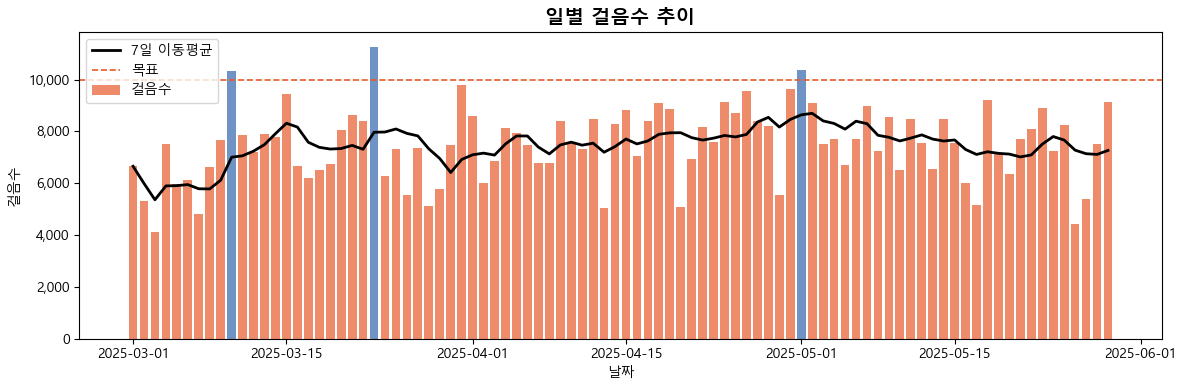

저장: graph_01_daily_steps.png


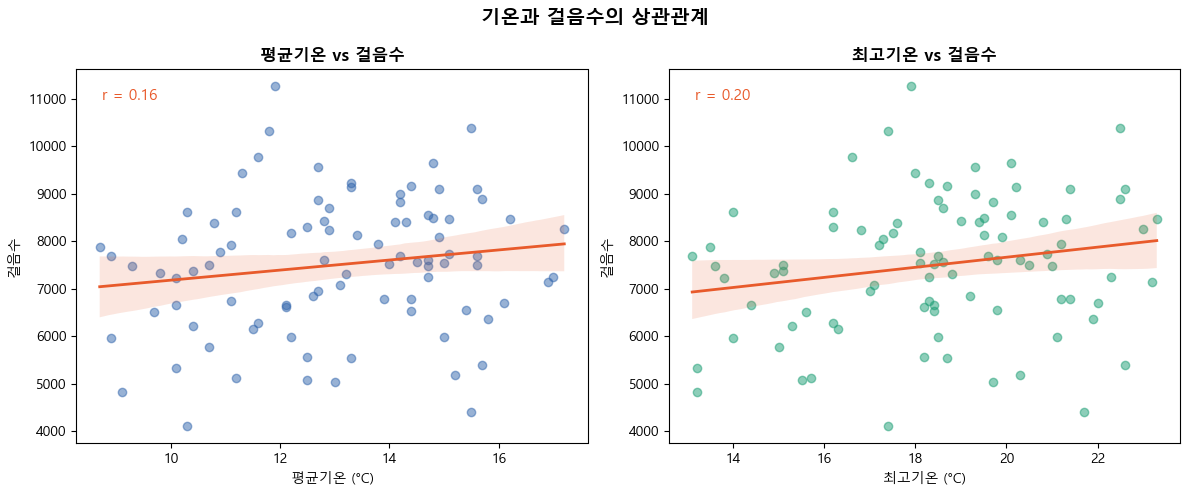

저장: graph_02_steps_vs_temp.png


C:\Users\Chosun\AppData\Local\Temp\ipykernel_13936\237819373.py:213: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='날씨', y='걸음수', order=order,


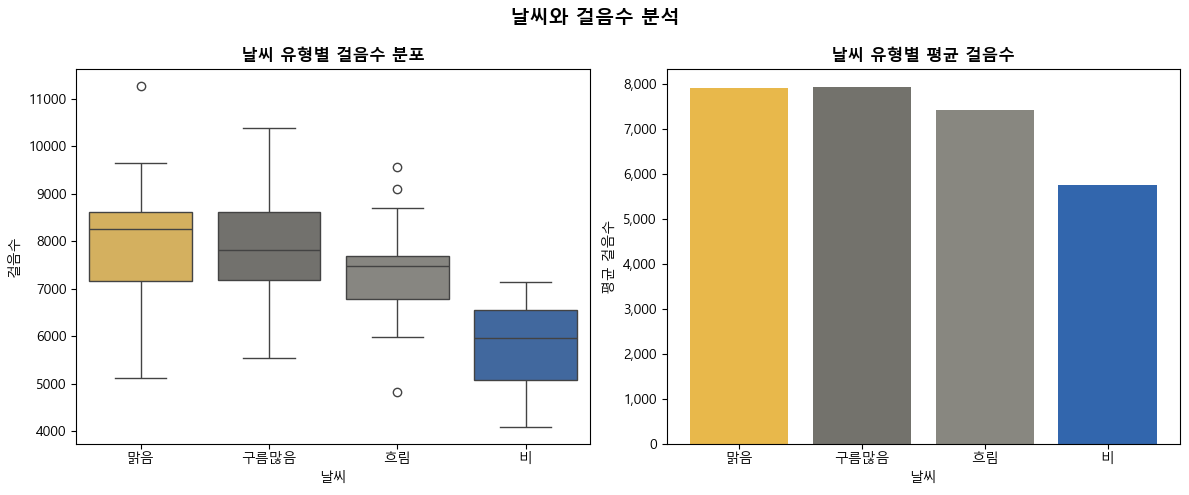

저장: graph_03_weather.png


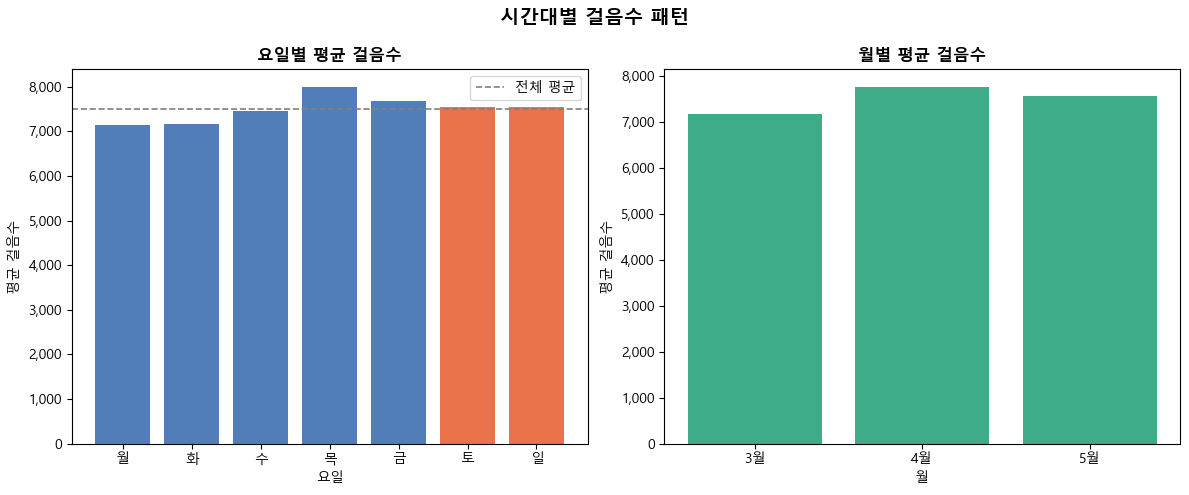

저장: graph_04_pattern.png


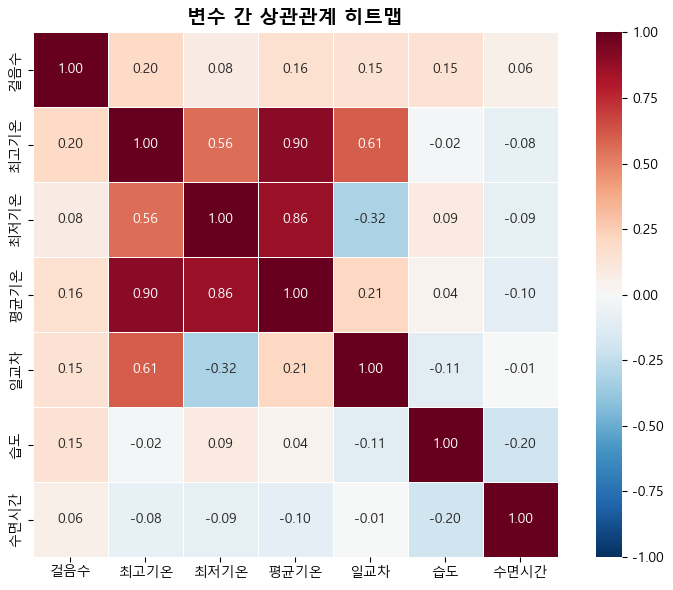

저장: graph_05_heatmap.png


C:\Users\Chosun\AppData\Local\Temp\ipykernel_13936\237819373.py:295: UserWarning: Glyph 127831 (\N{POULTRY LEG}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Chosun\AppData\Local\Temp\ipykernel_13936\237819373.py:296: UserWarning: Glyph 127831 (\N{POULTRY LEG}) missing from font(s) Malgun Gothic.
  plt.savefig('graph_06_points.png', dpi=150, bbox_inches='tight')
C:\Users\Chosun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127831 (\N{POULTRY LEG}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


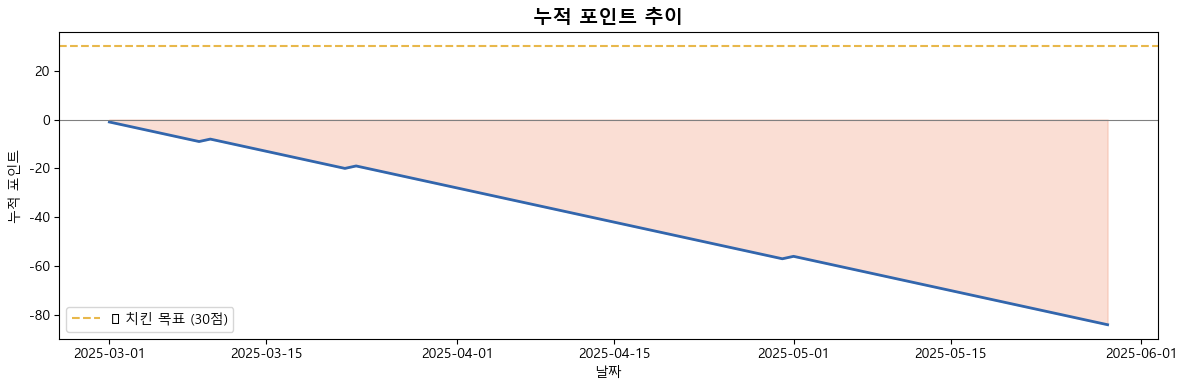

저장: graph_06_points.png


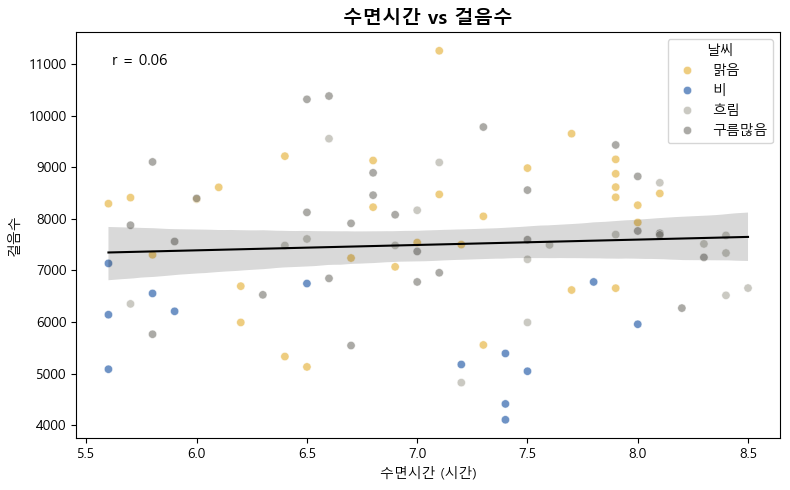

저장: graph_07_sleep.png

✅ 모든 그래프 저장 완료!


In [1]:
"""
걸음수 & 날씨 데이터 분석
데이터 기초 프로그래밍 과제 - 장수영
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
import csv
from datetime import datetime, timedelta
import random

# ─────────────────────────────────────────
# 0. 한글 폰트 설정
# ─────────────────────────────────────────
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    try:
        from matplotlib import font_manager
        font_path = font_manager.findSystemFonts(fontpaths=None, fontext='ttf')
        korean_fonts = [f for f in font_path if 'Nanum' in f or 'nanum' in f]
        if korean_fonts:
            font_manager.fontManager.addfont(korean_fonts[0])
            plt.rcParams['font.family'] = fm.FontProperties(fname=korean_fonts[0]).get_name()
    except:
        pass

plt.rcParams['axes.unicode_minus'] = False

# ─────────────────────────────────────────
# 1. 샘플 데이터 생성 (CSV 파일이 없을 때)
# ─────────────────────────────────────────

def generate_sample_data(n=90, filepath='steps_data.csv'):
    """90일치 샘플 데이터 생성 및 CSV 저장"""
    weathers = ['맑음', '맑음', '구름많음', '흐림', '비', '맑음', '구름많음']
    records = []
    base = datetime(2025, 3, 1)

    for i in range(n):
        date = base + timedelta(days=i)
        month_offset = date.month - 3
        base_temp = 5 + month_offset * 2.5

        tmax = round(base_temp + 8 + random.uniform(0, 6), 1)
        tmin = round(base_temp - 2 + random.uniform(0, 4), 1)
        weather = random.choice(weathers)
        humidity = random.randint(35, 80)
        sleep = round(random.uniform(5.5, 8.5), 1)

        # 날씨·기온에 따른 걸음수 (현실적인 패턴)
        base_steps = 7500
        temp_effect = (tmax - 15) * 150
        rain_penalty = -2500 if weather == '비' else 0
        sleep_effect = (sleep - 7) * 300
        noise = random.gauss(0, 1200)
        steps = max(1500, int(base_steps + temp_effect + rain_penalty + sleep_effect + noise))

        records.append({
            '날짜': date.strftime('%Y-%m-%d'),
            '걸음수': steps,
            '최고기온': tmax,
            '최저기온': tmin,
            '평균기온': round((tmax + tmin) / 2, 1),
            '날씨': weather,
            '습도': humidity,
            '수면시간': sleep,
            '목표걸음수': 10000
        })

    with open(filepath, 'w', newline='', encoding='utf-8-sig') as f:
        writer = csv.DictWriter(f, fieldnames=records[0].keys())
        writer.writeheader()
        writer.writerows(records)

    print(f"샘플 데이터 생성 완료: {filepath} ({n}일)")
    return filepath

# ─────────────────────────────────────────
# 2. 데이터 로드 및 전처리
# ─────────────────────────────────────────

def load_data(filepath='steps_data.csv'):
    """CSV 파일 로드 및 파생 컬럼 생성"""
    if not Path(filepath).exists():
        print(f"{filepath} 없음 → 샘플 데이터 생성")
        filepath = generate_sample_data()

    df = pd.read_csv(filepath, encoding='utf-8-sig')
    df['날짜'] = pd.to_datetime(df['날짜'])
    df = df.sort_values('날짜').reset_index(drop=True)

    # 파생 컬럼
    df['요일'] = df['날짜'].dt.day_name().map({
        'Monday': '월', 'Tuesday': '화', 'Wednesday': '수',
        'Thursday': '목', 'Friday': '금', 'Saturday': '토', 'Sunday': '일'
    })
    df['요일번호'] = df['날짜'].dt.dayofweek          # 0=월 ~ 6=일
    df['월'] = df['날짜'].dt.month
    df['주차'] = df['날짜'].dt.isocalendar().week.astype(int)
    df['목표달성'] = df['걸음수'] >= df['목표걸음수']
    df['포인트'] = df['목표달성'].map({True: 1, False: -1})
    df['누적포인트'] = df['포인트'].cumsum()
    df['평균기온'] = df.get('평균기온', ((df['최고기온'] + df['최저기온']) / 2).round(1))
    df['일교차'] = (df['최고기온'] - df['최저기온']).round(1)
    df['7일평균걸음수'] = df['걸음수'].rolling(7, min_periods=1).mean().round(0)

    return df

# ─────────────────────────────────────────
# 3. 포인트 / 보상 시스템
# ─────────────────────────────────────────

def print_reward_status(df):
    """포인트 현황 출력 (기존 과제 기능 확장)"""
    goal_steps = df['목표걸음수'].iloc[-1]
    total_days = len(df)
    achieved = df['목표달성'].sum()
    points = df['누적포인트'].iloc[-1]

    print("=" * 40)
    print("🏃 걸음수 보상 시스템 현황")
    print("=" * 40)
    print(f"기록 기간  : {df['날짜'].min().date()} ~ {df['날짜'].max().date()}")
    print(f"총 기록일수 : {total_days}일")
    print(f"목표 걸음수 : {goal_steps:,}보")
    print(f"목표 달성일 : {achieved}일 ({achieved/total_days*100:.1f}%)")
    print(f"누적 포인트 : {points:+d}점")
    print("-" * 40)
    if points >= 30:
        print("🍗 치킨 보상을 획득하셨습니다!")
    else:
        print(f"치킨까지 {30 - points}점 남았습니다")
    print("=" * 40)

# ─────────────────────────────────────────
# 4. 그래프 시각화 (matplotlib + seaborn)
# ─────────────────────────────────────────

COLORS = {
    'blue':  '#3266AD',
    'red':   '#E85A2B',
    'green': '#1D9E75',
    'amber': '#E8B84B',
    'gray':  '#888780',
}

def fig_daily_steps(df):
    """그래프 1: 일별 걸음수 & 7일 이동평균"""
    fig, ax = plt.subplots(figsize=(12, 4))
    colors = [COLORS['blue'] if g else COLORS['red'] for g in df['목표달성']]
    ax.bar(df['날짜'], df['걸음수'], color=colors, alpha=0.7, label='걸음수', width=0.8)
    ax.plot(df['날짜'], df['7일평균걸음수'], color='black', lw=2, label='7일 이동평균')
    ax.axhline(df['목표걸음수'].iloc[-1], color=COLORS['red'], ls='--', lw=1.2, label='목표')
    ax.set_title('일별 걸음수 추이', fontsize=14, fontweight='bold')
    ax.set_xlabel('날짜')
    ax.set_ylabel('걸음수')
    ax.legend()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig('graph_01_daily_steps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: graph_01_daily_steps.png")

def fig_steps_vs_temperature(df):
    """그래프 2: 기온 vs 걸음수 산점도 (seaborn)"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.regplot(data=df, x='평균기온', y='걸음수', ax=axes[0],
                scatter_kws={'alpha': 0.5, 'color': COLORS['blue']},
                line_kws={'color': COLORS['red'], 'lw': 2})
    axes[0].set_title('평균기온 vs 걸음수', fontweight='bold')
    axes[0].set_xlabel('평균기온 (°C)')
    axes[0].set_ylabel('걸음수')
    r = df[['평균기온', '걸음수']].corr().iloc[0, 1]
    axes[0].text(0.05, 0.95, f'r = {r:.2f}', transform=axes[0].transAxes,
                 va='top', fontsize=11, color=COLORS['red'])

    sns.regplot(data=df, x='최고기온', y='걸음수', ax=axes[1],
                scatter_kws={'alpha': 0.5, 'color': COLORS['green']},
                line_kws={'color': COLORS['red'], 'lw': 2})
    axes[1].set_title('최고기온 vs 걸음수', fontweight='bold')
    axes[1].set_xlabel('최고기온 (°C)')
    axes[1].set_ylabel('걸음수')
    r2 = df[['최고기온', '걸음수']].corr().iloc[0, 1]
    axes[1].text(0.05, 0.95, f'r = {r2:.2f}', transform=axes[1].transAxes,
                 va='top', fontsize=11, color=COLORS['red'])

    plt.suptitle('기온과 걸음수의 상관관계', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('graph_02_steps_vs_temp.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: graph_02_steps_vs_temp.png")

def fig_weather_analysis(df):
    """그래프 3: 날씨 유형별 걸음수 (seaborn)"""
    order = ['맑음', '구름많음', '흐림', '비', '눈']
    order = [w for w in order if w in df['날씨'].unique()]
    palette = {
        '맑음': COLORS['amber'], '구름많음': '#73726C',
        '흐림': COLORS['gray'], '비': COLORS['blue'], '눈': '#6DBBDA'
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.boxplot(data=df, x='날씨', y='걸음수', order=order,
                palette=palette, ax=axes[0])
    axes[0].set_title('날씨 유형별 걸음수 분포', fontweight='bold')
    axes[0].set_xlabel('날씨')
    axes[0].set_ylabel('걸음수')

    weather_avg = df.groupby('날씨')['걸음수'].mean().reindex(order)
    axes[1].bar(weather_avg.index, weather_avg.values,
                color=[palette.get(w, COLORS['gray']) for w in weather_avg.index])
    axes[1].set_title('날씨 유형별 평균 걸음수', fontweight='bold')
    axes[1].set_xlabel('날씨')
    axes[1].set_ylabel('평균 걸음수')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.suptitle('날씨와 걸음수 분석', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('graph_03_weather.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: graph_03_weather.png")

def fig_weekday_monthly(df):
    """그래프 4: 요일별 / 월별 평균 걸음수"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    weekday_order = ['월', '화', '수', '목', '금', '토', '일']
    weekday_avg = df.groupby('요일')['걸음수'].mean().reindex(weekday_order)
    wcolors = [COLORS['red'] if w in ['토', '일'] else COLORS['blue'] for w in weekday_order]
    axes[0].bar(weekday_avg.index, weekday_avg.values, color=wcolors, alpha=0.85)
    axes[0].set_title('요일별 평균 걸음수', fontweight='bold')
    axes[0].set_xlabel('요일')
    axes[0].set_ylabel('평균 걸음수')
    axes[0].axhline(df['걸음수'].mean(), ls='--', color='gray', lw=1.2, label='전체 평균')
    axes[0].legend()
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    monthly_avg = df.groupby('월')['걸음수'].mean()
    axes[1].bar(monthly_avg.index, monthly_avg.values, color=COLORS['green'], alpha=0.85)
    axes[1].set_title('월별 평균 걸음수', fontweight='bold')
    axes[1].set_xlabel('월')
    axes[1].set_ylabel('평균 걸음수')
    axes[1].set_xticks(monthly_avg.index)
    axes[1].set_xticklabels([f'{m}월' for m in monthly_avg.index])
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.suptitle('시간대별 걸음수 패턴', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('graph_04_pattern.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: graph_04_pattern.png")

def fig_correlation_heatmap(df):
    """그래프 5: 상관관계 히트맵 (seaborn)"""
    cols = ['걸음수', '최고기온', '최저기온', '평균기온', '일교차', '습도', '수면시간']
    cols = [c for c in cols if c in df.columns]
    corr = df[cols].corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, center=0, ax=ax,
                square=True, linewidths=0.5)
    ax.set_title('변수 간 상관관계 히트맵', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('graph_05_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: graph_05_heatmap.png")

def fig_cumulative_points(df):
    """그래프 6: 누적 포인트 추이 & 치킨 목표선"""
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df['날짜'], df['누적포인트'], color=COLORS['blue'], lw=2)
    ax.fill_between(df['날짜'], df['누적포인트'], 0,
                    where=df['누적포인트'] >= 0,
                    alpha=0.2, color=COLORS['blue'])
    ax.fill_between(df['날짜'], df['누적포인트'], 0,
                    where=df['누적포인트'] < 0,
                    alpha=0.2, color=COLORS['red'])
    ax.axhline(30, color=COLORS['amber'], ls='--', lw=1.5, label='🍗 치킨 목표 (30점)')
    ax.axhline(0, color='gray', lw=0.8, ls='-')
    ax.set_title('누적 포인트 추이', fontsize=14, fontweight='bold')
    ax.set_xlabel('날짜')
    ax.set_ylabel('누적 포인트')
    ax.legend()
    plt.tight_layout()
    plt.savefig('graph_06_points.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: graph_06_points.png")

def fig_sleep_steps(df):
    """그래프 7: 수면시간 vs 걸음수 (seaborn)"""
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=df, x='수면시간', y='걸음수',
                    hue='날씨', palette={
                        '맑음': COLORS['amber'], '구름많음': COLORS['gray'],
                        '흐림': '#B4B2A9', '비': COLORS['blue'], '눈': '#6DBBDA'
                    }, alpha=0.7, ax=ax)
    sns.regplot(data=df, x='수면시간', y='걸음수', scatter=False,
                line_kws={'color': 'black', 'lw': 1.5}, ax=ax)
    r = df[['수면시간', '걸음수']].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, va='top', fontsize=11)
    ax.set_title('수면시간 vs 걸음수', fontsize=14, fontweight='bold')
    ax.set_xlabel('수면시간 (시간)')
    ax.set_ylabel('걸음수')
    plt.tight_layout()
    plt.savefig('graph_07_sleep.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장: graph_07_sleep.png")

# ─────────────────────────────────────────
# 5. 통계 요약
# ─────────────────────────────────────────

def print_statistics(df):
    """주요 통계 출력"""
    print("\n" + "=" * 40)
    print("📊 데이터 통계 요약")
    print("=" * 40)
    print(f"평균 걸음수    : {df['걸음수'].mean():,.0f}보")
    print(f"최대 걸음수    : {df['걸음수'].max():,}보 ({df.loc[df['걸음수'].idxmax(), '날짜'].date()})")
    print(f"최소 걸음수    : {df['걸음수'].min():,}보 ({df.loc[df['걸음수'].idxmin(), '날짜'].date()})")
    print(f"표준편차      : {df['걸음수'].std():,.0f}보")
    print()
    print(f"기온-걸음수 상관  : r = {df[['평균기온','걸음수']].corr().iloc[0,1]:.2f}")
    print(f"수면-걸음수 상관  : r = {df[['수면시간','걸음수']].corr().iloc[0,1]:.2f}")
    print(f"습도-걸음수 상관  : r = {df[['습도','걸음수']].corr().iloc[0,1]:.2f}")
    print("=" * 40)

# ─────────────────────────────────────────
# 6. 걸음수 입력 (기존 과제 기능 유지)
# ─────────────────────────────────────────

def interactive_input():
    """날짜별 걸음수 입력 및 포인트 계산 (원래 과제 기능)"""
    records = {}
    goal_steps = int(input("목표 걸음수를 입력하세요 (기본 10000): ") or 10000)

    print("걸음수를 입력하세요. 종료하려면 'q' 입력")
    while True:
        date_input = input("날짜 (예: 2025-06-07) 또는 'q': ").strip()
        if date_input.lower() == 'q':
            break
        steps_input = input(f"{date_input} 걸음수: ").strip()
        if not steps_input.isdigit():
            print("숫자를 입력하세요")
            continue
        records[date_input] = int(steps_input)

    if not records:
        return

    points = 0
    for date, steps in records.items():
        if steps >= goal_steps:
            points += 1
            print(f"{date}: {steps:,}보 ✓ (+1점)")
        else:
            points -= 1
            print(f"{date}: {steps:,}보 ✗ (-1점)")

    print(f"\n누적 포인트: {points:+d}")
    if points >= 30:
        print("🍗 치킨 보상을 획득하셨습니다!")
    else:
        print(f"치킨까지 {30-points}점 남았습니다")

# ─────────────────────────────────────────
# 메인 실행
# ─────────────────────────────────────────

if __name__ == '__main__':
    print("데이터 로드 중...")
    df = load_data('steps_data.csv')

    print_reward_status(df)
    print_statistics(df)

    print("\n그래프 생성 중...")
    fig_daily_steps(df)
    fig_steps_vs_temperature(df)
    fig_weather_analysis(df)
    fig_weekday_monthly(df)
    fig_correlation_heatmap(df)
    fig_cumulative_points(df)
    fig_sleep_steps(df)

    print("\n✅ 모든 그래프 저장 완료!")